Paso 4. Análisis exploratorio de datos (Python)

In [6]:
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats as st

In [8]:
datos_de_la_compañia = pd.read_csv('moved_project_sql_result_01.csv')
datos_de_los_viajes = pd.read_csv('moved_project_sql_result_04.csv')
datos_de_los_viajes_2 = pd.read_csv('moved_project_sql_result_07.csv')

In [ ]:
datos_de_la_compañia.info()
display(datos_de_la_compañia.head(10))
# company_name: nombre de la empresa de taxis # trips_amount: el número de viajes de cada compañía de taxis el 15 y 16 de noviembre de 2017. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


In [10]:
datos_de_los_viajes.info()
display(datos_de_los_viajes.head(10))
# dropoff_location_name: barrios de Chicago donde finalizaron los viajes
# average_trips: el promedio de viajes que terminaron en cada barrio en noviembre de 2017

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


In [11]:
principales_barrios = datos_de_los_viajes['average_trips'].sort_values(ascending=False)
print(principales_barrios.head())

0    10727.466667
1     9523.666667
2     6664.666667
3     5163.666667
4     2546.900000
Name: average_trips, dtype: float64


Hacer gráficos:
Empresas de taxis y número de viajes
Los 10 barrios principales por número de finalizaciones

#EMPRESAS DE TAXIS Y NUMERO DE VIAJES#
##Los 10 barrios principales por número de finalizaciones##

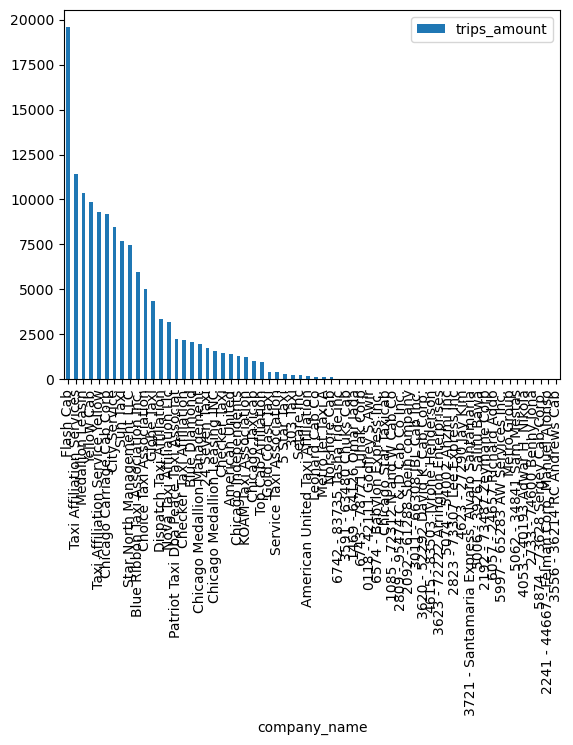

In [ ]:
datos_de_la_compañia.plot(x='company_name', kind='bar')
plt.show()

#LOS 10 PRINCIPALES BARRIOS EN TERMINOS DE FINALIZACION DE RECORRIDO#

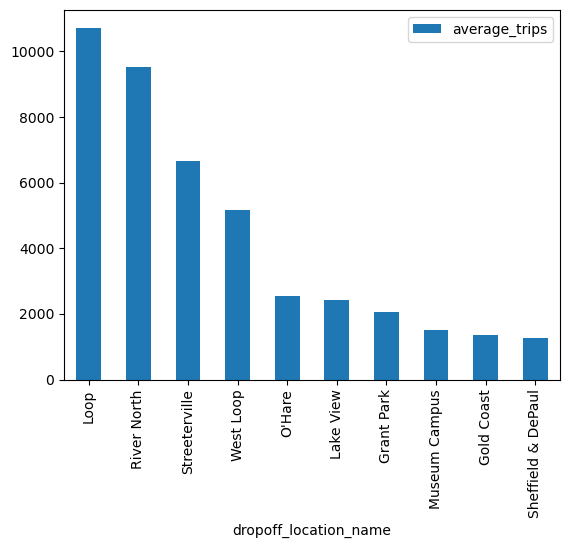

In [13]:
# datos_de_los_viajes # dropoff_location_name: barrios de Chicago donde finalizaron los viajes
# average_trips: el promedio de viajes que terminaron en cada barrio en noviembre de 2017
principales_barrios = datos_de_los_viajes.sort_values(by='average_trips', ascending = False).head(10)
#print(principales_barrios)
principales_barrios.plot(x='dropoff_location_name', y='average_trips', kind='bar')
plt.show()

#CONCLUSIONES#

¿Cómo se ven los gráficos visualmente?
R= Muy claros y revelan informacion importante a considerar.
¿Puedes interpretar fácilmente cuáles son las empresas de taxis más activas y los barrios más populares para finalizar viajes?
R= Claro Flash Cab la empresa mas activa y los barrios mas populares son Loop y River North.

In [18]:
# datos_de_los_viajes_2
# start_ts: fecha y hora de la recogida
# weather_conditions: condiciones climáticas en el momento en el que comenzó el viaje
# duration_seconds: duración del viaje en segundos
# Contiene datos sobre viajes: 
# desde el Loop hasta el Aeropuerto Internacional O'Hare. 
datos_de_los_viajes_2.info()
display(datos_de_los_viajes_2.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
 3   day_of_week         1068 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 33.5+ KB


,start_ts,weather_conditions,duration_seconds,day_of_week
0,2017-11-25 16:00:00,Good,2410.0,Saturday
1,2017-11-25 14:00:00,Good,1920.0,Saturday
2,2017-11-25 12:00:00,Good,1543.0,Saturday
3,2017-11-04 10:00:00,Good,2512.0,Saturday
4,2017-11-11 07:00:00,Good,1440.0,Saturday
5,2017-11-11 04:00:00,Good,1320.0,Saturday
6,2017-11-04 16:00:00,Bad,2969.0,Saturday
7,2017-11-18 11:00:00,Good,2280.0,Saturday
8,2017-11-11 14:00:00,Good,2460.0,Saturday
9,2017-11-11 12:00:00,Good,2040.0,Saturday


In [ ]:
# "La duración promedio de los viajes desde el Loop 
# hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"
# print(datos_de_los_viajes_2['weather_conditions'].unique())
# Convierte la columna start_ts a datetime
datos_de_los_viajes_2['start_ts'] = pd.to_datetime(datos_de_los_viajes_2['start_ts'])
# Ahora sí podemos extraer el día de la semana
datos_de_los_viajes_2['day_of_week'] = datos_de_los_viajes_2['start_ts'].dt.day_name()
# filtramos los datos para obtener solo los viajes que ocurrieron en sábados con mal clima
sabados_mal_clima = datos_de_los_viajes_2[
    (datos_de_los_viajes_2['day_of_week'] == 'Saturday')&
    (datos_de_los_viajes_2['weather_conditions'] == 'Bad')
    ]
print(sabados_mal_clima)

                start_ts weather_conditions  duration_seconds day_of_week
6    2017-11-04 16:00:00                Bad            2969.0    Saturday
30   2017-11-18 12:00:00                Bad            1980.0    Saturday
34   2017-11-04 17:00:00                Bad            2460.0    Saturday
51   2017-11-04 16:00:00                Bad            2760.0    Saturday
52   2017-11-18 12:00:00                Bad            2460.0    Saturday
...                  ...                ...               ...         ...
1031 2017-11-18 12:00:00                Bad            2560.0    Saturday
1032 2017-11-18 10:00:00                Bad            1908.0    Saturday
1053 2017-11-18 12:00:00                Bad            2400.0    Saturday
1061 2017-11-18 16:00:00                Bad            2186.0    Saturday
1067 2017-11-04 16:00:00                Bad            2834.0    Saturday

[180 rows x 4 columns]


In [ ]:
# Cargar datos frescos para el grupo de comparación
datos_originales = pd.read_csv('moved_project_sql_result_07.csv')
datos_originales['start_ts'] = pd.to_datetime(datos_originales['start_ts'])
datos_originales['day_of_week'] = datos_originales['start_ts'].dt.day_name()
# Creamos el grupo de sábados con buen clima
sabados_buen_clima = datos_originales[
    (datos_originales['day_of_week'] == 'Saturday') & 
    (datos_originales['weather_conditions'] == 'Good')
]
print(sabados_buen_clima)
print(f"Sábados con mal clima: {len(sabados_mal_clima)}")
print(f"Sábados con buen clima: {len(sabados_buen_clima)}")

                start_ts weather_conditions  duration_seconds day_of_week
0    2017-11-25 16:00:00               Good            2410.0    Saturday
1    2017-11-25 14:00:00               Good            1920.0    Saturday
2    2017-11-25 12:00:00               Good            1543.0    Saturday
3    2017-11-04 10:00:00               Good            2512.0    Saturday
4    2017-11-11 07:00:00               Good            1440.0    Saturday
...                  ...                ...               ...         ...
1062 2017-11-11 06:00:00               Good            1500.0    Saturday
1063 2017-11-25 11:00:00               Good               0.0    Saturday
1064 2017-11-11 10:00:00               Good            1318.0    Saturday
1065 2017-11-11 13:00:00               Good            2100.0    Saturday
1066 2017-11-11 08:00:00               Good            1380.0    Saturday

[888 rows x 4 columns]
Sábados con mal clima: 180
Sábados con buen clima: 888


In [23]:
print(f"Promedio en Sábados con mal clima: {(sabados_mal_clima['duration_seconds'].mean())}")
print(f"Promedio en Sábados con buen clima: {(sabados_buen_clima['duration_seconds'].mean())}")

Promedio en Sábados con mal clima: 2427.2055555555557
Promedio en Sábados con buen clima: 1999.6756756756756


Promedio en Sábados con mal clima: 2427.2055555555557
Promedio en Sábados con buen clima: 1999.6756756756756

In [24]:
# Cuál es nuestra hipótesis nula (H₀)? 
# No hay diferencia en la duración promedio de los viajes entre sábados con mal clima y sábados con buen clima.
# En términos matemáticos: μ₁ = μ₂ (donde μ₁ es el promedio con mal clima y μ₂ es el promedio con buen clima)

#¿Qué estamos tratando de probar o refutar? 
# Los sábados con mal clima tienen una duración promedio mayor que los sábados con buen clima.

#¿Cuál es nuestra hipótesis alternativa (H₁)?
# H₁: Los sábados con mal clima tienen una duración promedio mayor que los sábados con buen clima.
# En términos matemáticos: μ₁ > μ₂

alpha = 0.05 # nivel de significación estadística
# realizar una prueba
results = st.ttest_ind(sabados_mal_clima['duration_seconds'], sabados_buen_clima['duration_seconds'])

# imprimir el valor p resultante
print('valor p: ', results.pvalue)

# comparar el valor p con el umbral
if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  6.517970327099473e-12
Rechazamos la hipótesis nula


valor p:  6.517970327099473e-12
Rechazamos la hipótesis nula

Cómo planteaste las hipótesis nula y alternativa:
R= Al observar los promedios tanto de mal clima como de buen clima pudimos darnos cuenta que al mayor promedio lo tenia los viajes con mal clima y el menor promedio los de con buen clima,
por lo tanto nos formulamos la primera hipotesis nula "No hay diferencia en la duración promedio de los viajes entre sábados con mal clima y sábados con buen clima".
y para refutar la anterior realizamos una hipotesis alternativa la cual seria "Los sábados con mal clima tienen una duración promedio mayor que los sábados con buen clima".
Qué criterio usaste para probar las hipótesis y por que?
Tenemos estos resultados
Promedio con mal clima: 2,427 segundos (≈ 40.5 minutos)
Promedio con buen clima: 1,999 segundos (≈ 33.3 minutos)
con un nivel de significación estadística de 0.05 como valor alpha
a la hora realizar la prueba buscaremos que que si el valor p resultante es < alpha entonces Rechazamos H₀: No es cierto que las duraciones promedio sean iguales
su sucede lo opuesto entonces Aceptamos H₁: Los sábados con mal clima SÍ tienen una duración promedio significativamente mayor que los sábados con buen clima
